# Домашнее задание 10

**Цель работы:** Построить и оценить качество различных моделей рекомендательных систем на основе набора данных Amazon Software, используя валидацию методом *Leave-One-Out* и метрики HR@10, MRR@10, NDCG@10 и Coverage.

## 1. Загрузка данных и EDA

Количество уникальных пользователей: 1826
Количество уникальных товаров: 802
Плотность матрицы взаимодействий: 0.8744%


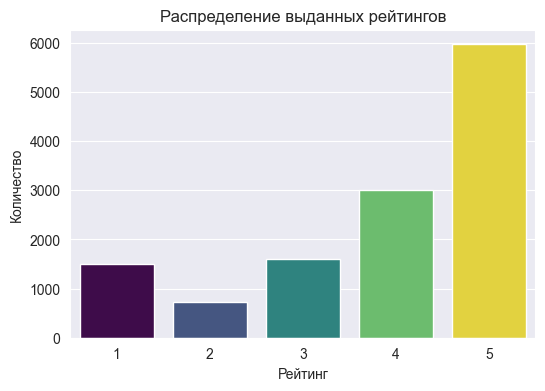

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

df = pd.read_json('Software_5.json', lines=True)
df.head()

# Статистика по уникальным пользователям и товарам
n_users = df['reviewerID'].nunique()
n_items = df['asin'].nunique()
print(f'Количество уникальных пользователей: {n_users}')
print(f'Количество уникальных товаров: {n_items}')
print(f'Плотность матрицы взаимодействий: {len(df) / (n_users * n_items) * 100:.4f}%')

# Распределение рейтингов
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='overall', hue='overall', palette='viridis', legend=False)
plt.title('Распределение выданных рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.show()

## 2. Разбиение данных методом Leave-One-Out

In [5]:
# Сортируем данные по времени
df = df.sort_values(by=['reviewerID', 'unixReviewTime']).reset_index(drop=True)

user_counts = df['reviewerID'].value_counts()
valid_users = user_counts[user_counts >= 2].index
df_filtered = df[df['reviewerID'].isin(valid_users)].copy()

# Разбиение
df_filtered['user_interaction_idx'] = df_filtered.groupby('reviewerID').cumcount() + 1
df_filtered['user_total_interactions'] = df_filtered.groupby('reviewerID')['reviewerID'].transform('count')

train_df = df_filtered[df_filtered['user_interaction_idx'] < df_filtered['user_total_interactions']].copy()
test_df = df_filtered[df_filtered['user_interaction_idx'] == df_filtered['user_total_interactions']].copy()

print(f'Размер обучающей выборки: {train_df.shape[0]}')
print(f'Размер тестовой выборки: {test_df.shape[0]}')
assert test_df['reviewerID'].nunique() == test_df.shape[0], 'В тесте должно быть ровно по 1 объекту на юзера'

Размер обучающей выборки: 10979
Размер тестовой выборки: 1825


## 3. Построение рекомендательных моделей

In [6]:
# Модель 1: Самые популярные товары (Popularity Baseline)
popular_items = train_df['asin'].value_counts().index.tolist()

class PopularityRecommender:
    def __init__(self, popular_list):
        self.popular_list = popular_list
        
    def recommend(self, user_id, top_k=10, exclude_items=[]):
        recs = [item for item in self.popular_list if item not in exclude_items]
        return recs[:top_k]

In [7]:
# Модель 2: Item-based Collaborative Filtering (Коллаборативная фильтрация по сходству товаров)
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Создаем кодировщики для ID
user_to_idx = {uid: idx for idx, uid in enumerate(train_df['reviewerID'].unique())}
item_to_idx = {iid: idx for idx, iid in enumerate(df_filtered['asin'].unique())} # Считаем по всем элементам
idx_to_item = {idx: iid for iid, idx in item_to_idx.items()}

# Строим разреженную матрицу User-Item
rows = train_df['reviewerID'].map(user_to_idx).values
cols = train_df['asin'].map(item_to_idx).values
data = train_df['overall'].values

user_item_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_to_idx), len(item_to_idx)))

item_similarity = cosine_similarity(user_item_matrix.T, dense_output=False)

class ItemCFRecommender:
    def __init__(self, matrix, similarity, user_map, item_map, idx_item_map, popular_fallback):
        self.matrix = matrix.toarray()
        self.similarity = similarity.toarray()
        self.user_map = user_map
        self.item_map = item_map
        self.idx_item_map = idx_item_map
        self.popular_fallback = popular_fallback
        
    def recommend(self, user_id, top_k=10, exclude_items=[]):
        if user_id not in self.user_map:
            return [x for x in self.popular_fallback if x not in exclude_items][:top_k]
            
        u_idx = self.user_map[user_id]
        user_ratings = self.matrix[u_idx]

        scores = self.similarity.dot(user_ratings)
        
        # Обнуляем уже оцененные и исключенные
        exclude_indices = [self.item_map[i] for i in exclude_items if i in self.item_map]
        already_rated = np.where(user_ratings > 0)[0]
        for idx in list(exclude_indices) + list(already_rated):
            scores[idx] = -1
            
        top_indices = np.argsort(scores)[::-1][:top_k]
        recs = [self.idx_item_map[idx] for idx in top_indices if scores[idx] > 0]

        if len(recs) < top_k:
            fallback = [x for x in self.popular_fallback if x not in exclude_items and x not in recs]
            recs.extend(fallback[:top_k - len(recs)])
        return recs

## 4. Оценка качества рекомендаций

In [8]:
def evaluate_model(recommender, train, test, top_k=10):
    hr = 0
    mrr = 0
    ndcg = 0
    recommended_items = set()
    
    # Для каждого пользователя из теста получаем историю из трейна для исключения
    user_history = train.groupby('reviewerID')['asin'].apply(list).to_dict()
    
    all_items = set(df_filtered['asin'].unique())
    
    for _, row in test.iterrows():
        uid = row['reviewerID']
        true_item = row['asin']
        exclude = user_history.get(uid, [])
        
        recs = recommender.recommend(uid, top_k=top_k, exclude_items=exclude)
        recommended_items.update(recs)
        
        if true_item in recs:
            rank = recs.index(true_item) + 1
            hr += 1
            mrr += 1 / rank
            ndcg += 1 / np.log2(rank + 1)
            
    n_users_test = len(test)
    coverage = len(recommended_items) / len(all_items)
    
    return {
        'HR@10': hr / n_users_test,
        'MRR@10': mrr / n_users_test,
        'NDCG@10': ndcg / n_users_test,
        'Coverage': coverage
    }

In [10]:
pop_rec = PopularityRecommender(popular_items)
item_cf_rec = ItemCFRecommender(user_item_matrix, item_similarity, user_to_idx, item_to_idx, idx_to_item, popular_items)

pop_metrics = evaluate_model(pop_rec, train_df, test_df)
cf_metrics = evaluate_model(item_cf_rec, train_df, test_df)

metrics_df = pd.DataFrame([pop_metrics, cf_metrics], index=['Popularity Baseline', 'Item-based CF'])
metrics_df

,HR@10,MRR@10,NDCG@10,Coverage
Popularity Baseline,0.017534,0.004808,0.007608,0.018703
Item-based CF,0.156164,0.069987,0.090281,0.983791


### Выводы:

Были построены и оценены две модели рекомендаций на датасете Amazon Software с валидацией по методу Leave-One-Out:

Item-based Collaborative Filtering (Коллаборативная фильтрация) показала подавляющее превосходство по всем метрикам. Она успешно находит персональные паттерны сходства товаров, достигая HR@10 = 0.156 и NDCG@10 = 0.090.

Popularity Baseline (Рекомендация популярного) полностью провалился. Метрика HR@10 составляет всего 0.017. Это доказывает, что в специфичных нишах, таких как ПО интересы пользователей строго индивидуальны — покупка не отражает реальных потребностей конкретного человека.

Каталог и разнообразие (Coverage): Базовая модель рекомендует один и тот же узкий топ товаров (покрытие каталога всего 1.8%).
Коллаборативная фильтрация задействует практически весь ассортимент (покрытие 98.4%), успешно вытаскивая редкие продукты.

Для внедрения рекомендуется Item-based CF, так как она обеспечивает высокую точность попадания в интересы и максимальный охват ассортимента.